In [ ]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [2]:
def spd_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov',
    'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov',
    'ai_OOB_quantile', 'lc_OOB_quantile', 'le_OOB_quantile'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'results'))):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'results/' + file)), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'df': file.split('_')[3][2:],
            'ai_i_cov': [result['ai_i_cov']],
            'ai_ii_cov': [result['ai_ii_cov']],
            'ai_iii_cov': [result['ai_iii_cov']],
            'ai_iv_cov': [result['ai_iv_cov']],
            'lc_i_cov': [result['lc_i_cov']],
            'lc_ii_cov': [result['lc_ii_cov']],
            'lc_iii_cov': [result['lc_iii_cov']],
            'lc_iv_cov': [result['lc_iv_cov']],
            'le_i_cov': [result['le_i_cov']],
            'le_ii_cov': [result['le_ii_cov']],
            'le_iii_cov': [result['le_iii_cov']],
            'le_iv_cov': [result['le_iv_cov']],
            'ai_OOB_quantile': [result['ai_OOB_quantile']],
            'lc_OOB_quantile': [result['lc_OOB_quantile']],
            'le_OOB_quantile': [result['le_OOB_quantile']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['df'] = coverage_df.df.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters
q = 2

Prediction balls

In [3]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
SPD_coverage_df=spd_coverage_results()
SPD_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79


,sample_index,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,lc_i_cov,lc_ii_cov,lc_iii_cov,lc_iv_cov,le_i_cov,le_ii_cov,le_iii_cov,le_iv_cov,ai_OOB_quantile,lc_OOB_quantile,le_OOB_quantile
0,41,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.969, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.992, 0.976, 0.926]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.945, 0.917]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.999, 0.935, 0.907]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.969, 0.937]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.996, 0.974, 0.924]","[1.505679230581571, 1.2579673991562705, 1.0762...","[0.918354742676609, 0.6653153919267066, 0.6079...","[1.5440177084785984, 1.2308301961216592, 1.081..."
1,49,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.991, 0.939, 0.884]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.938, 0.903]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.95, 0.888]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.929, 0.849]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.991, 0.934, 0.873]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.936, 0.882]","[1.4221752141807402, 1.1164169448065224, 0.999...","[0.8538510259068304, 0.6937193107003314, 0.592...","[1.4246174088868753, 1.098106717939617, 0.9688..."
2,50,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.963, 0.922, 0.876]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.958, 0.907]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.958, 0.904, 0.838]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.969, 0.924]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.959, 0.906, 0.88]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.945, 0.908]","[1.3578632408460451, 1.146902250821157, 1.0230...","[0.7444777564643998, 0.6416938960961125, 0.564...","[1.3176451854175004, 1.1008886173858512, 1.034..."
3,45,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.943, 0.918]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.949, 0.922]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.989, 0.936, 0.871]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.933, 0.891]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.991, 0.947, 0.917]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.953, 0.922]","[3.52177184196071, 2.317213828086618, 2.107170...","[1.641163645829105, 1.2339524389898677, 1.1003...","[3.237552872140376, 2.302037275247895, 2.07546..."
4,43,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.96, 0.924, 0.855]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.962, 0.905]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.953, 0.942, 0.854]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.981, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.958, 0.928, 0.867]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.968, 0.909]","[1.3947903174329694, 1.172861572126778, 1.0226...","[0.7593558430465642, 0.7119804438825651, 0.569...","[1.3478212547793287, 1.1948813841910348, 1.031..."


In [4]:
ai_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov', 'ai_OOB_quantile']]
lc_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'lc_OOB_quantile']]
le_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov', 'le_OOB_quantile']]

# TYPE I

In [5]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_i_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_i_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_i['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_i['df_' + str(df)][str(N)] = lc_means
            le_diccionario_i['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_i, lc_diccionario_i, le_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_i, lc_diccionario_i, le_diccionario_i = calculate_type_i_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_i

{'df_5': {'50': [array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1. , 1. , 0.7]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.8]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.7]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.8]),
   array([1. , 1. , 0.8]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([0.9, 0.9, 0.8]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([0.9, 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([0.9, 0.8, 0.7]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 1.

Prediction balls

In [6]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [7]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.80 (3.25)  96.40 (5.57)  87.00 (10.44)
   100              97.20 (5.31)  94.00 (7.21)  87.80 (11.01)
   200              98.20 (4.33)  96.40 (5.92)   93.40 (8.63)
   500              98.80 (3.25)  95.60 (5.71)   91.80 (8.65)
15 50               99.80 (1.40)  96.40 (5.57)   90.80 (8.68)
   100              99.40 (2.37)  92.60 (8.67)  88.00 (10.20)
   200              97.40 (4.82)  92.60 (7.70)  88.40 (10.46)
   500              99.00 (3.00)  96.40 (5.57)   89.80 (8.60)

In [8]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 96.40 (5.57) & 87.00 (10.44) \\
\textbf{} & \textbf{100} & 97.20 (5.31) & 94.00 (7.21) & 87.80 (11.01) \\
\textbf{} & \textbf{200} & 98.20 (4.33) & 96.40 (5.92) & 93.40 (8.63) \\
\textbf{} & \textbf{500} & 98.80 (3.25) & 95.60 (5.71) & 91.80 (8.65) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.80 (1.40) & 96.40 (5.57) & 90.80 (8.68) \\
\textbf{} & \textbf{100} & 99.40 (2.37) & 92.60 (8.67) & 88.00 (10.20) \\
\textbf{} & \textbf{200} & 97.40 (4.82) & 92.60 (7.70) & 88.40 (10.46) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 96.40 (5.57) & 89.80 (8.60) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/1377484444.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [9]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.80 (3.25)  93.40 (7.10)   89.00 (9.85)
   100              97.60 (4.72)  94.80 (6.08)   89.40 (8.35)
   200              98.60 (3.47)  95.00 (7.00)   91.40 (8.95)
   500              98.40 (3.67)  97.60 (4.27)   92.40 (8.14)
15 50               99.20 (2.71)  95.20 (5.74)   91.60 (8.33)
   100              98.40 (3.67)  93.20 (8.35)  88.00 (10.39)
   200              97.80 (4.60)  93.80 (7.72)  90.00 (10.20)
   500              98.80 (3.25)  94.80 (7.00)   89.40 (9.68)

In [10]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:lc_typeIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type I error}
\label{tab:lc_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 93.40 (7.10) & 89.00 (9.85) \\
\textbf{} & \textbf{100} & 97.60 (4.72) & 94.80 (6.08) & 89.40 (8.35) \\
\textbf{} & \textbf{200} & 98.60 (3.47) & 95.00 (7.00) & 91.40 (8.95) \\
\textbf{} & \textbf{500} & 98.40 (3.67) & 97.60 (4.27) & 92.40 (8.14) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.20 (2.71) & 95.20 (5.74) & 91.60 (8.33) \\
\textbf{} & \textbf{100} & 98.40 (3.67) & 93.20 (8.35) & 88.00 (10.39) \\
\textbf{} & \textbf{200} & 97.80 (4.60) & 93.80 (7.72) & 90.00 (10.20) \\
\textbf{} & \textbf{500} & 98.80 (3.25) & 94.80 (7.00) & 89.40 (9.68) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/1770482267.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [11]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.80 (3.25)  96.80 (5.81)   88.40 (9.46)
   100              97.20 (5.31)  93.20 (7.05)  87.60 (10.87)
   200              98.20 (4.33)  96.80 (5.08)   93.40 (8.15)
   500              98.80 (3.25)  95.60 (5.35)   90.20 (9.48)
15 50               99.80 (1.40)  96.20 (5.62)   90.80 (8.21)
   100              99.00 (3.00)  92.00 (8.72)  88.00 (10.77)
   200              97.80 (4.60)  92.80 (7.76)  87.80 (10.45)
   500              99.00 (3.00)  96.40 (5.57)   89.60 (8.94)

In [12]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 96.80 (5.81) & 88.40 (9.46) \\
\textbf{} & \textbf{100} & 97.20 (5.31) & 93.20 (7.05) & 87.60 (10.87) \\
\textbf{} & \textbf{200} & 98.20 (4.33) & 96.80 (5.08) & 93.40 (8.15) \\
\textbf{} & \textbf{500} & 98.80 (3.25) & 95.60 (5.35) & 90.20 (9.48) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.80 (1.40) & 96.20 (5.62) & 90.80 (8.21) \\
\textbf{} & \textbf{100} & 99.00 (3.00) & 92.00 (8.72) & 88.00 (10.77) \\
\textbf{} & \textbf{200} & 97.80 (4.60) & 92.80 (7.76) & 87.80 (10.45) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 96.40 (5.57) & 89.60 (8.94) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/691899972.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# TYPE II

### df 5

In [13]:
ai_ii_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_ii_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_ii_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_ii_SPD_coverage_df_df_5_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_5_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_5_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_5_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_5_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_5_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_5_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_5_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_5_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_5_alpha_01.head()
ai_ii_SPD_coverage_df_df_5_alpha_05.head()
ai_ii_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
3,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.918,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.949, 0.922]",2.107170
5,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.893,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.954, 0.897]",1.926155
6,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.756,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.967, 0.928, 0.75]",1.714332
7,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.901,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.993, 0.95, 0.881]",1.940810
8,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.876,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.943, 0.882]",1.870917


### df 15

In [14]:
ai_ii_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_ii_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_ii_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_ii_SPD_coverage_df_df_15_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_15_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_15_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_15_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_15_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_15_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_15_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_15_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_15_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_15_alpha_01.head()
ai_ii_SPD_coverage_df_df_15_alpha_05.head()
ai_ii_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.934,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.992, 0.976, 0.926]",1.076250
1,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.884,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.938, 0.903]",0.999852
2,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.876,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.958, 0.907]",1.023074
4,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.855,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.962, 0.905]",1.022697
9,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.889,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.996, 0.942, 0.9]",0.999113


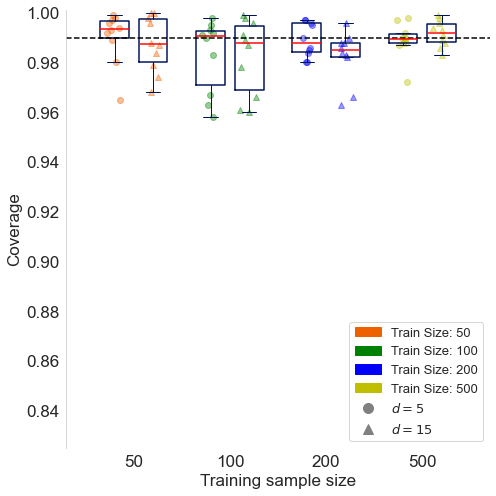

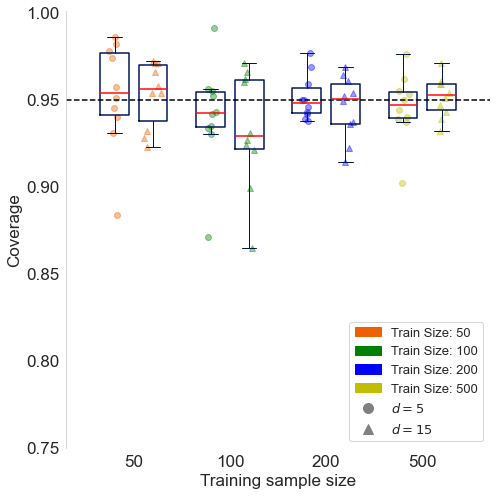

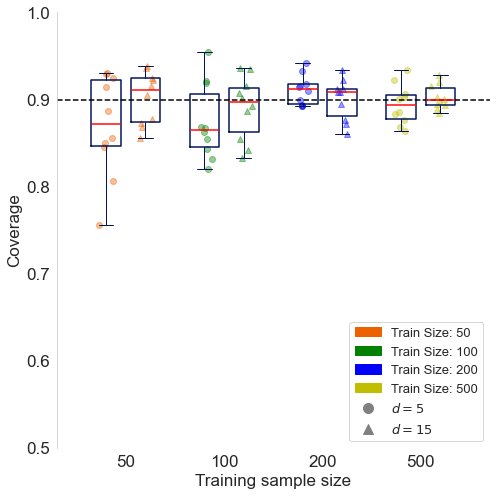

In [16]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')
palette = ['#ee6100', 'g', 'b', 'y']


for df_5_data, df_15_data, alpha_level in zip(
    [ai_ii_SPD_coverage_df_df_5_alpha_01, ai_ii_SPD_coverage_df_df_5_alpha_05, ai_ii_SPD_coverage_df_df_5_alpha_1], 
    [ai_ii_SPD_coverage_df_df_15_alpha_01, ai_ii_SPD_coverage_df_df_15_alpha_05, ai_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'ai_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

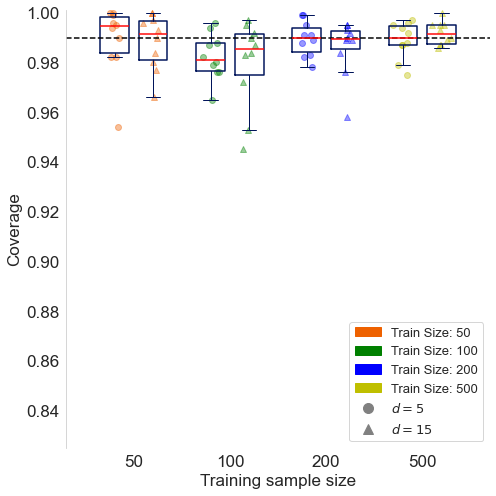

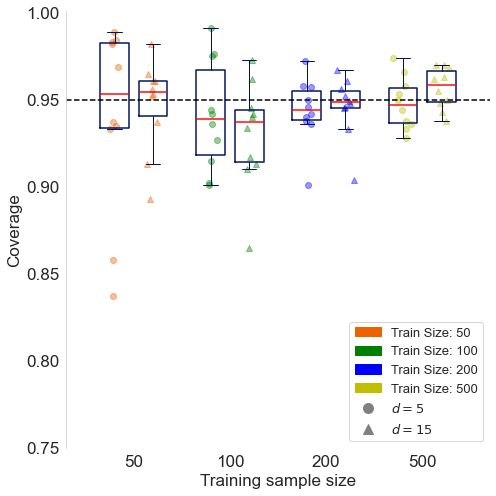

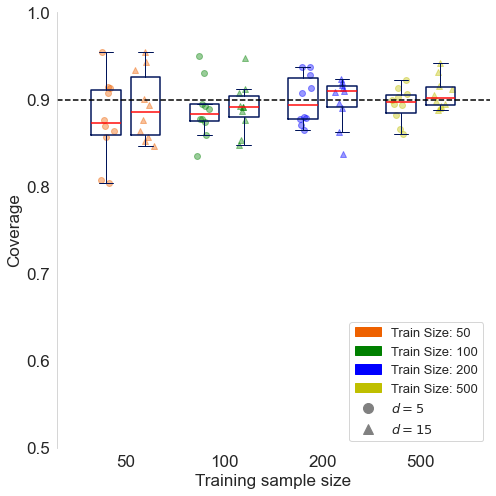

In [17]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for df_5_data, df_15_data, alpha_level in zip(
    [lc_ii_SPD_coverage_df_df_5_alpha_01, lc_ii_SPD_coverage_df_df_5_alpha_05, lc_ii_SPD_coverage_df_df_5_alpha_1], 
    [lc_ii_SPD_coverage_df_df_15_alpha_01, lc_ii_SPD_coverage_df_df_15_alpha_05, lc_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'lc_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

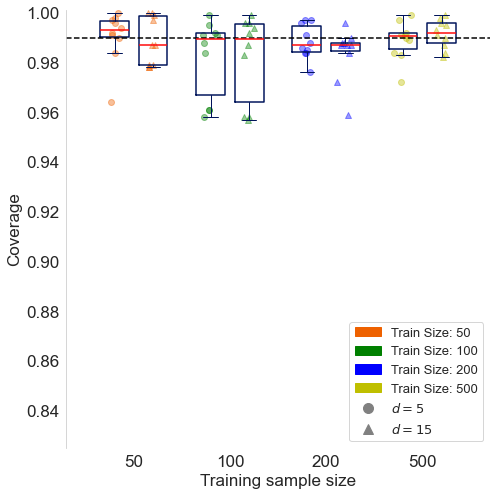

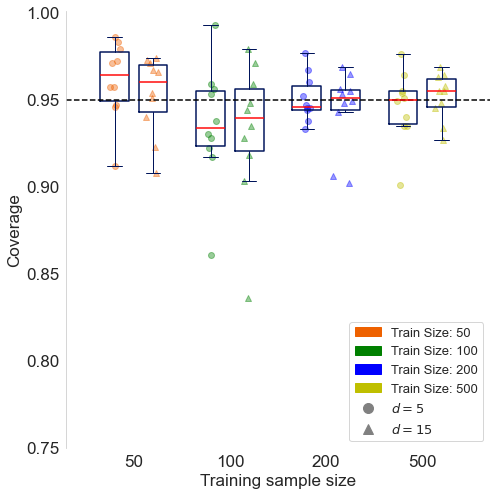

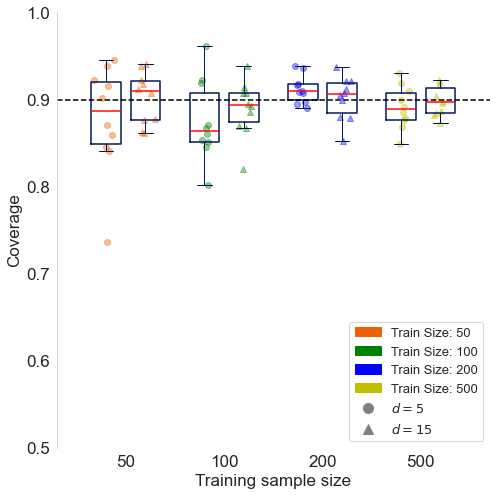

In [18]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')
palette = ['#ee6100', 'g', 'b', 'y']

for df_5_data, df_15_data, alpha_level in zip(
    [le_ii_SPD_coverage_df_df_5_alpha_01, le_ii_SPD_coverage_df_df_5_alpha_05, le_ii_SPD_coverage_df_df_5_alpha_1], 
    [le_ii_SPD_coverage_df_df_15_alpha_01, le_ii_SPD_coverage_df_df_15_alpha_05, le_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'le_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

In [19]:
ai_SPD_coverage_df_alpha_01 = ai_SPD_coverage_df.copy()
ai_SPD_coverage_df_alpha_05 = ai_SPD_coverage_df.copy()
ai_SPD_coverage_df_alpha_1  = ai_SPD_coverage_df.copy()

ai_SPD_coverage_df_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[0])
ai_SPD_coverage_df_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[1])
ai_SPD_coverage_df_alpha_1['ai_OOB_quantile'] = ai_SPD_coverage_df['ai_OOB_quantile'].apply(lambda x: x[2])

lc_SPD_coverage_df_alpha_01 = lc_SPD_coverage_df.copy()
lc_SPD_coverage_df_alpha_05 = lc_SPD_coverage_df.copy()
lc_SPD_coverage_df_alpha_1  = lc_SPD_coverage_df.copy()

lc_SPD_coverage_df_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[0])
lc_SPD_coverage_df_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[1])
lc_SPD_coverage_df_alpha_1['lc_OOB_quantile'] = lc_SPD_coverage_df['lc_OOB_quantile'].apply(lambda x: x[2])

le_SPD_coverage_df_alpha_01 = le_SPD_coverage_df.copy()
le_SPD_coverage_df_alpha_05 = le_SPD_coverage_df.copy()
le_SPD_coverage_df_alpha_1  = le_SPD_coverage_df.copy()

le_SPD_coverage_df_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[0])
le_SPD_coverage_df_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[1])
le_SPD_coverage_df_alpha_1['le_OOB_quantile'] = le_SPD_coverage_df['le_OOB_quantile'].apply(lambda x: x[2])

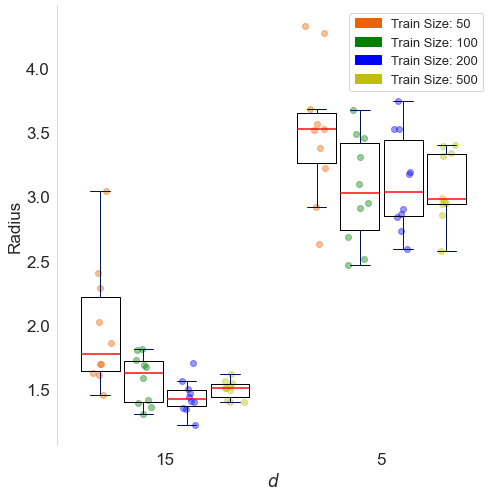

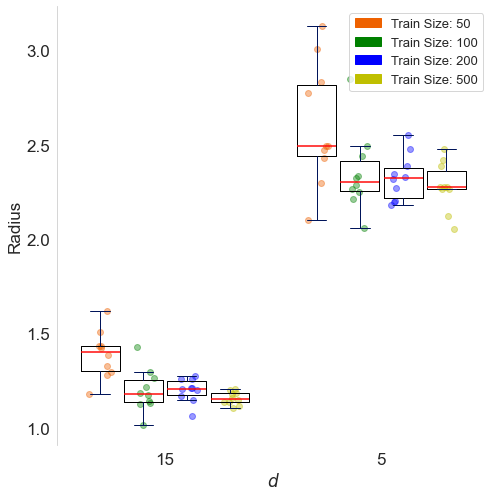

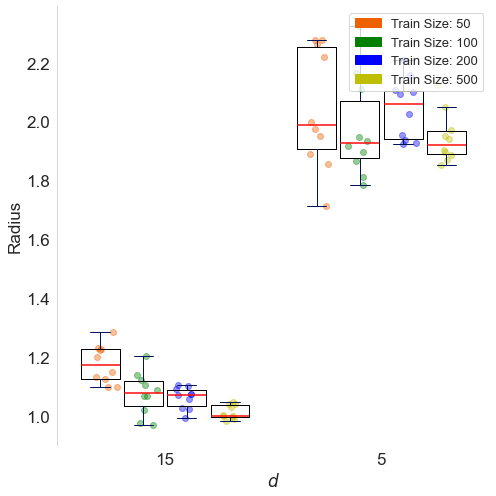

In [20]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ai_SPD_coverage_df_alpha_01, ai_SPD_coverage_df_alpha_05, ai_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ai_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ai_SPD_coverage_df_alpha_05
    else:
        coverage_df = ai_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'ai_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, showfliers=False, medianprops=medianprops,showmeans=False) 

            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines
    sns.set_style("whitegrid")

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'ai_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

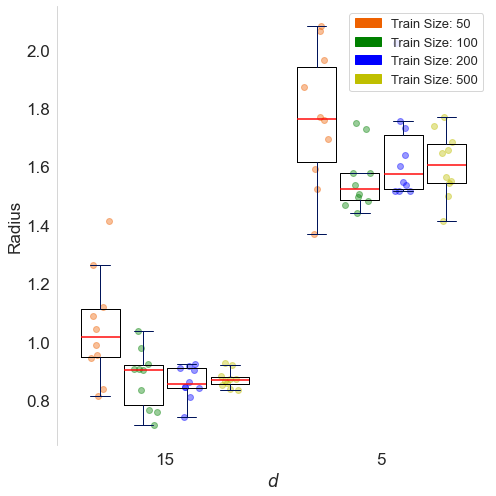

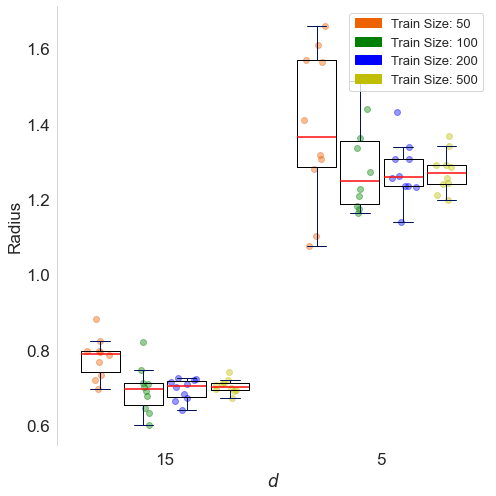

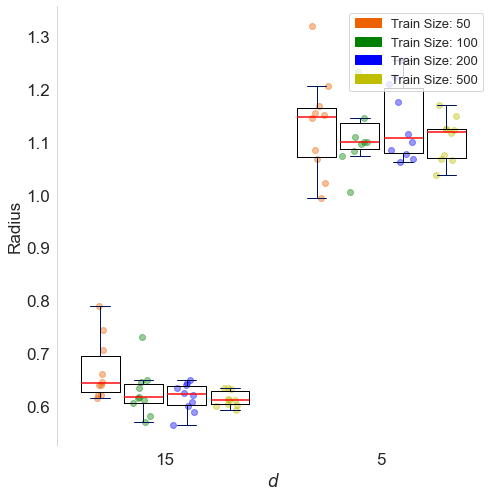

In [21]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [lc_SPD_coverage_df_alpha_01, lc_SPD_coverage_df_alpha_05, lc_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = lc_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = lc_SPD_coverage_df_alpha_05
    else:
        coverage_df = lc_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'lc_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, showfliers=False, medianprops=medianprops,showmeans=False) 

            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines
    sns.set_style("whitegrid")

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'lc_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

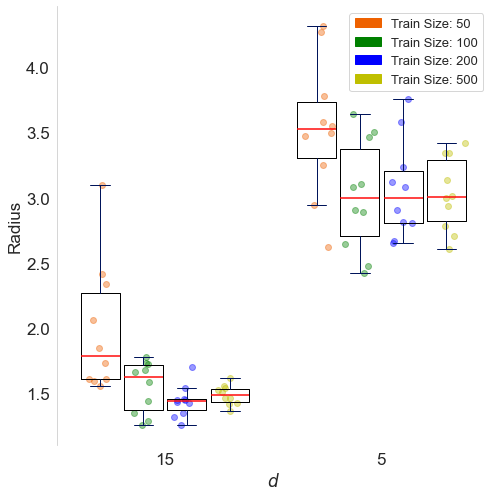

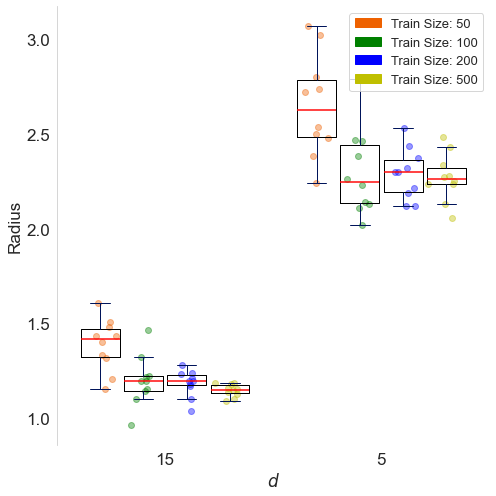

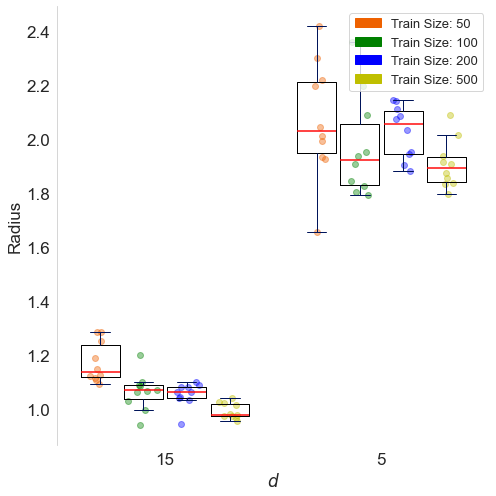

In [22]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [le_SPD_coverage_df_alpha_01, le_SPD_coverage_df_alpha_05, le_SPD_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = le_SPD_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = le_SPD_coverage_df_alpha_05
    else:
        coverage_df = le_SPD_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = coverage_df['df'].unique()
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['df'] == df) & (coverage_df['train_size'] == N), 'le_OOB_quantile']
            for N in train_sizes]
        for df in dfs ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, showfliers=False, medianprops=medianprops,showmeans=False) 

            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines
    sns.set_style("whitegrid")

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
        
    ax.set_xlabel(r'$d$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'le_SPD_radius_vs_df_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [23]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_iii_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_iii_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_iii['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_iii['df_' + str(df)][str(N)] = lc_means
            le_diccionario_iii['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii = calculate_type_iii_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_iii

{'df_5': {'50': [array([1., 1., 1.]),
   array([1. , 0.9, 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1. , 1. , 0.8]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.7]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.7]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([0.9, 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.8]),
   array([1. , 0.9, 0.8]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.8]),
   ar

Prediction balls

In [24]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [25]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               99.40 (2.37)  96.40 (5.92)  89.20 (8.91)
   100              99.40 (2.37)  96.20 (5.62)  92.00 (8.94)
   200              99.00 (3.00)  95.00 (7.00)  92.60 (9.12)
   500              99.00 (3.00)  96.60 (5.14)  92.40 (7.63)
15 50               99.80 (1.40)  99.00 (3.61)  96.00 (5.29)
   100              99.20 (2.71)  95.60 (6.05)  92.60 (7.43)
   200              97.80 (5.02)  95.40 (6.07)  90.60 (8.58)
   500              99.00 (3.00)  95.20 (6.71)  91.80 (8.65)

In [26]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 99.40 (2.37) & 96.40 (5.92) & 89.20 (8.91) \\
\textbf{} & \textbf{100} & 99.40 (2.37) & 96.20 (5.62) & 92.00 (8.94) \\
\textbf{} & \textbf{200} & 99.00 (3.00) & 95.00 (7.00) & 92.60 (9.12) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 96.60 (5.14) & 92.40 (7.63) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.80 (1.40) & 99.00 (3.61) & 96.00 (5.29) \\
\textbf{} & \textbf{100} & 99.20 (2.71) & 95.60 (6.05) & 92.60 (7.43) \\
\textbf{} & \textbf{200} & 97.80 (5.02) & 95.40 (6.07) & 90.60 (8.58) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 95.20 (6.71) & 91.80 (8.65) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/2564002804.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [27]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05           0.1
df N                                                        
5  50               99.60 (1.96)  96.40 (5.57)  89.80 (8.36)
   100              99.00 (3.00)  94.80 (6.71)  89.80 (8.60)
   200              99.00 (3.00)  93.40 (8.39)  90.20 (9.90)
   500              98.60 (3.47)  96.20 (5.25)  91.60 (7.03)
15 50               99.80 (1.40)  98.20 (3.84)  95.20 (6.08)
   100              98.60 (3.47)  95.40 (6.07)  91.60 (7.03)
   200              99.20 (2.71)  94.20 (7.51)  90.40 (8.94)
   500              99.40 (2.37)  95.60 (6.68)  90.80 (8.21)

In [28]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:lc_typeIIIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type III error}
\label{tab:lc_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 99.60 (1.96) & 96.40 (5.57) & 89.80 (8.36) \\
\textbf{} & \textbf{100} & 99.00 (3.00) & 94.80 (6.71) & 89.80 (8.60) \\
\textbf{} & \textbf{200} & 99.00 (3.00) & 93.40 (8.39) & 90.20 (9.90) \\
\textbf{} & \textbf{500} & 98.60 (3.47) & 96.20 (5.25) & 91.60 (7.03) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.80 (1.40) & 98.20 (3.84) & 95.20 (6.08) \\
\textbf{} & \textbf{100} & 98.60 (3.47) & 95.40 (6.07) & 91.60 (7.03) \\
\textbf{} & \textbf{200} & 99.20 (2.71) & 94.20 (7.51) & 90.40 (8.94) \\
\textbf{} & \textbf{500} & 99.40 (2.37) & 95.60 (6.68) & 90.80 (8.21) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/587411137.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [29]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level           0.01          0.05           0.1
df N                                                         
5  50                99.40 (2.37)  97.60 (4.27)  90.00 (8.94)
   100               99.60 (1.96)  96.00 (6.00)  92.00 (7.48)
   200               98.80 (3.25)  95.00 (7.00)  92.60 (9.12)
   500               99.40 (2.37)  96.80 (5.08)  92.40 (8.14)
15 50               100.00 (0.00)  99.00 (3.00)  96.60 (5.14)
   100               98.60 (3.47)  95.80 (6.03)  92.40 (7.89)
   200               98.00 (4.47)  95.60 (6.05)  90.80 (8.45)
   500               99.00 (3.00)  94.60 (6.70)  91.60 (8.57)

In [30]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:le_typeIIIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type III error}
\label{tab:le_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 99.40 (2.37) & 97.60 (4.27) & 90.00 (8.94) \\
\textbf{} & \textbf{100} & 99.60 (1.96) & 96.00 (6.00) & 92.00 (7.48) \\
\textbf{} & \textbf{200} & 98.80 (3.25) & 95.00 (7.00) & 92.60 (9.12) \\
\textbf{} & \textbf{500} & 99.40 (2.37) & 96.80 (5.08) & 92.40 (8.14) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 100.00 (0.00) & 99.00 (3.00) & 96.60 (5.14) \\
\textbf{} & \textbf{100} & 98.60 (3.47) & 95.80 (6.03) & 92.40 (7.89) \\
\textbf{} & \textbf{200} & 98.00 (4.47) & 95.60 (6.05) & 90.80 (8.45) \\
\textbf{} & \textbf{500} & 99.00 (3.00) & 94.60 (6.70) & 91.60 (8.57) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_66030/2909853705.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# Type IV

Hacemos todo con $X=0.25$.

### df 5

In [31]:
ai_iv_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_iv_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_iv_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_iv_SPD_coverage_df_df_5_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_5_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_5_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_5_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_5_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_5_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_5_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_5_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_5_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_5_alpha_01.head()
ai_iv_SPD_coverage_df_df_5_alpha_05.head()
ai_iv_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
3,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.943, 0.918]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.922,2.107170
5,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.985, 0.95, 0.893]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.897,1.926155
6,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.945, 0.756]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.750,1.714332
7,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.955, 0.901]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.881,1.940810
8,500,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.953, 0.876]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.882,1.870917


## df 15

In [32]:
ai_iv_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_iv_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_iv_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_iv_SPD_coverage_df_df_15_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_15_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_15_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_15_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_15_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_15_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_15_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_15_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_15_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_15_alpha_01.head()
ai_iv_SPD_coverage_df_df_15_alpha_05.head()
ai_iv_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.969, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.926,1.076250
1,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.991, 0.939, 0.884]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.903,0.999852
2,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.963, 0.922, 0.876]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.907,1.023074
4,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.96, 0.924, 0.855]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.905,1.022697
9,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.989, 0.932, 0.889]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.900,0.999113


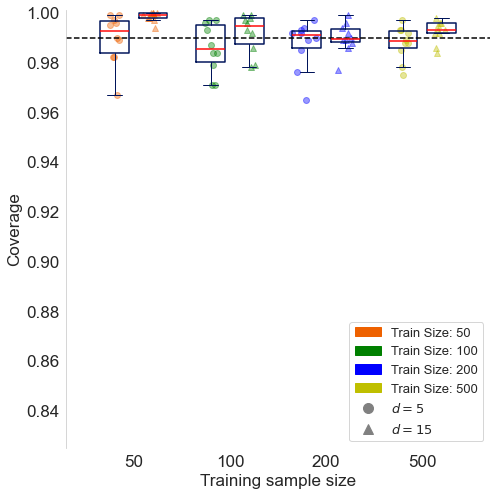

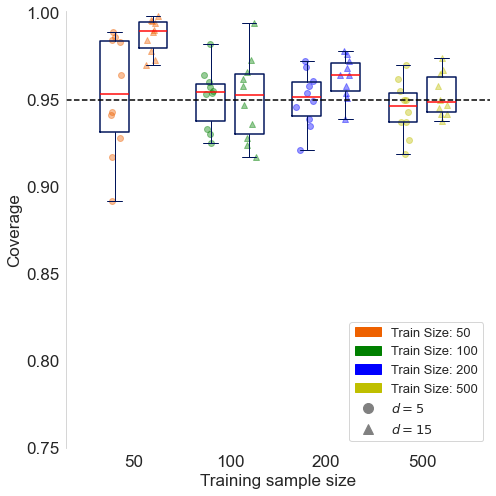

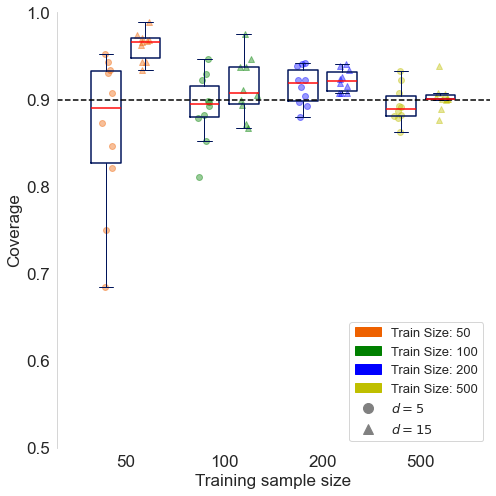

In [33]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [ai_iv_SPD_coverage_df_df_5_alpha_01, ai_iv_SPD_coverage_df_df_5_alpha_05, ai_iv_SPD_coverage_df_df_5_alpha_1],
    [ai_iv_SPD_coverage_df_df_15_alpha_01, ai_iv_SPD_coverage_df_df_15_alpha_05, ai_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'ai_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

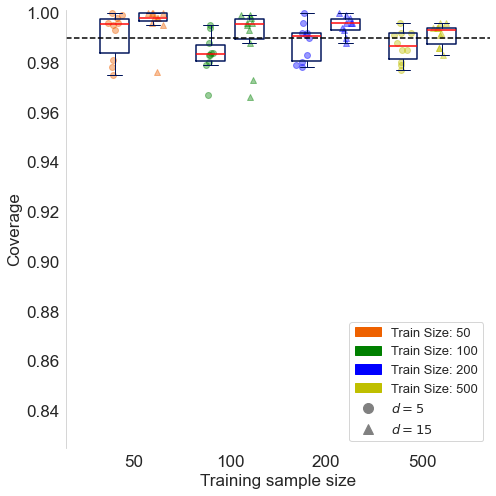

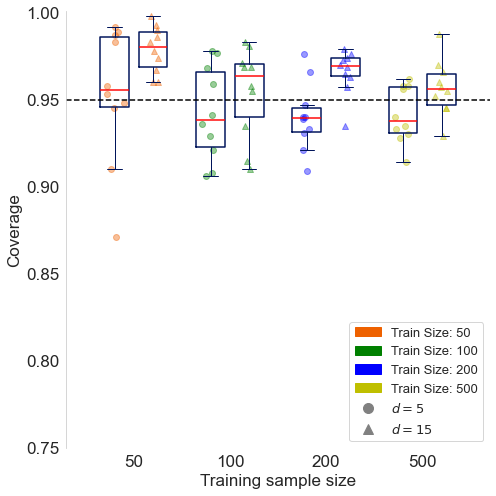

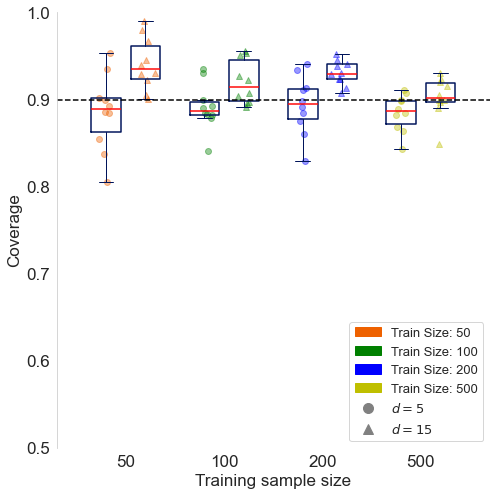

In [34]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [lc_iv_SPD_coverage_df_df_5_alpha_01, lc_iv_SPD_coverage_df_df_5_alpha_05, lc_iv_SPD_coverage_df_df_5_alpha_1],
    [lc_iv_SPD_coverage_df_df_15_alpha_01, lc_iv_SPD_coverage_df_df_15_alpha_05, lc_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'lc_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

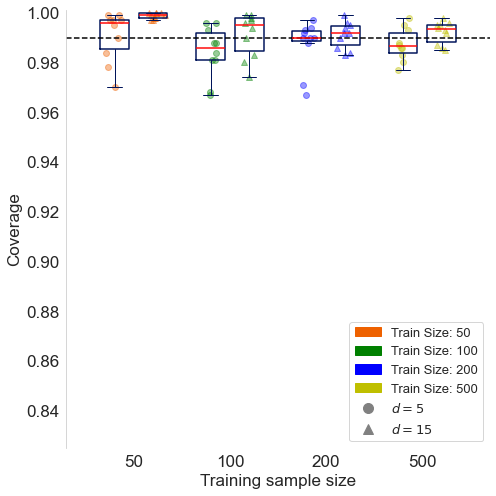

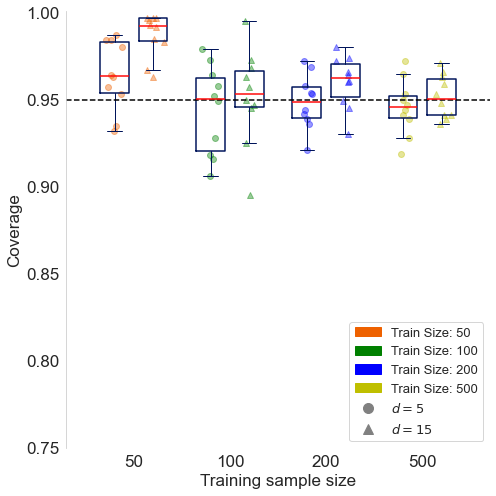

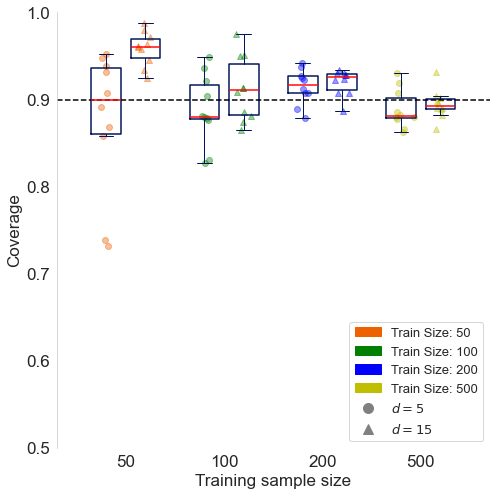

In [35]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [le_iv_SPD_coverage_df_df_5_alpha_01, le_iv_SPD_coverage_df_df_5_alpha_05, le_iv_SPD_coverage_df_df_5_alpha_1],
    [le_iv_SPD_coverage_df_df_15_alpha_01, le_iv_SPD_coverage_df_df_15_alpha_05, le_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['le_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['le_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}')
        for j in range(len(train_sizes))
    ]
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'))

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'le_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()